In [2]:
import sys
import os

# Add the parent directory (project root) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))

## GLM4v

### Load model

In [3]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Glm4vForConditionalGeneration

model_id = "zai-org/GLM-4.1V-9B-Thinking"

def load_glm_model(model_id):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id, use_fast=True)

    model = Glm4vForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        device_map="cuda",                  # split across GPU/CPU automatically
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor

In [4]:
model_id = "zai-org/GLM-4.1V-9B-Thinking"
model, processor = load_glm_model(model_id)
model.eval()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Glm4vForConditionalGeneration(
  (model): Glm4vModel(
    (visual): Glm4vVisionModel(
      (embeddings): Glm4vVisionEmbeddings(
        (position_embedding): Embedding(576, 1536)
      )
      (patch_embed): Glm4vVisionPatchEmbed(
        (proj): Conv3d(3, 1536, kernel_size=(2, 14, 14), stride=(2, 14, 14))
      )
      (rotary_pos_emb): Glm4vVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Glm4vVisionBlock(
          (norm1): Glm4vRMSNorm((1536,), eps=1e-05)
          (norm2): Glm4vRMSNorm((1536,), eps=1e-05)
          (attn): Glm4vVisionAttention(
            (qkv): Linear4bit(in_features=1536, out_features=4608, bias=False)
            (proj): Linear4bit(in_features=1536, out_features=1536, bias=False)
          )
          (mlp): Glm4VisionMlp(
            (gate_proj): Linear4bit(in_features=1536, out_features=4096, bias=False)
            (up_proj): Linear4bit(in_features=1536, out_features=4096, bias=False)
            (down_proj): Linear4bit(in_features=

In [5]:
# --- your provided strings ---
GLM_SYSTEM_MESSAGE = """

You are a careful and efficient reasoning model for structured information extraction from visual documents.

Your reasoning should be:

 

1. **Concise** – express reasoning in as few words as needed to remain clear.

2. **Coherent** – progress step-by-step without jumping back or restating the same ideas.

3. **Progress-Oriented** – avoid loops or circling back to the same step.

4. **Non-Repetitive** – never repeat a sentence or phrase more than once in reasoning.

 - If a value or idea is already stated, refer to it briefly rather than repeating it verbatim.

 - If a field value is long (e.g., multiple sentences), summarize it instead of copying it in full multiple times.

5. **Fail Gracefully** – if you cannot confidently find a field, return `None` for that field. Do not guess.

6. **Respect Field Boundaries** – reasoning should mention field names briefly, and keep the value mentions short.

7. **Token Discipline** – do not excess 500 tokens for reasoning.

 

---

 

### Examples of Good Reasoning vs. Bad Reasoning

 

**Example 1 – Avoiding Thinking Loops**

Bad:

Reasoning Step 1: The invoice number is in the top right.

Reasoning Step 2: The invoice number is in the top right.

Reasoning Step 3: The invoice number is in the top right.

 

Good:

Reasoning Step 1: Located invoice number in top right corner.

Reasoning Step 2: Extracted value "INV-2034".

 

---

 

**Example 2 – Avoiding stating overly Long Field Values when reasoning**

Bad:

Reasoning: Found comment: "The client requests delivery by 5 PM and prefers packaging in green boxes. Additionally, they request a follow-up call within 2 days."

 

Good:

Reasoning: Found comment about delivery time, packaging color, and follow-up call.

 

---

 

**Example 3 – Returning None When Unsure**

Bad:

Reasoning: Could not find PO number, guessing "PO-9999".

 

Good:

Reasoning: PO number not found → returning `None`.

 

---

 

Follow these principles for **every step** of your reasoning trace. Output reasoning first, then final structured result.

 

"""

PROMPT = """

Extract information from the provided document ONLY if you are confident.

**Field values can be extracted from textual content, tables, and checkboxes contained in the document.**

If a field's value cannot be confidently extracted (e.g., it is missing, unclear, or illegible), set its value to None.

Do not guess or make up answers. Return the extracted data in JSON format according to the schema below.

 

Output schema:

{

{% for field_name in schema%}

    "{{ field_name }}": "extracted value for field {{field_name}}"{% if not loop.last %},{% endif %}

{% endfor %}

}

"""



In [6]:
# If you don't actually use Jinja at runtime, just build the schema string yourself.
fields = [
    "ubo first names",
    "ubo last names",
    "ubo birth date",
    "ubo city of birth",
    "ubo country of birth",
    "ubo citizenships",
    "ubo current private adress",
    "ubo current business adress",
    "position occupied by exposed person",
    "nature of relationship exposed person",
    "type UBO",
    "Type of Beneficial Owner (1, 2, 3 or 4)",
    "Type of ownership (the total % of direct and indirect ownership)",
    "the UBO person is politically exposed or have been politically expose last year",
    "the politically exposed person exert significant influence over public institutions, organizations or companies",
    "a related person to the UBO person is politically exposed",
]

# Replace the Jinja loop with an explicit schema snippet (simple + robust).
schema_block = "{\n" + ",\n".join([f'  "{f}": "extracted value for field {f}"' for f in fields]) + "\n}"
user_text = PROMPT.replace(
    "{\n{% for field_name in schema%}\n    \"{{ field_name }}\": \"extracted value for field {{field_name}}\"{% if not loop.last %},{% endif %}\n\n{% endfor %}\n}\n",
    schema_block
)

In [7]:
print(schema_block)

{
  "ubo first names": "extracted value for field ubo first names",
  "ubo last names": "extracted value for field ubo last names",
  "ubo birth date": "extracted value for field ubo birth date",
  "ubo city of birth": "extracted value for field ubo city of birth",
  "ubo country of birth": "extracted value for field ubo country of birth",
  "ubo citizenships": "extracted value for field ubo citizenships",
  "ubo current private adress": "extracted value for field ubo current private adress",
  "ubo current business adress": "extracted value for field ubo current business adress",
  "position occupied by exposed person": "extracted value for field position occupied by exposed person",
  "nature of relationship exposed person": "extracted value for field nature of relationship exposed person",
  "type UBO": "extracted value for field type UBO",
  "Type of Beneficial Owner (1, 2, 3 or 4)": "extracted value for field Type of Beneficial Owner (1, 2, 3 or 4)",
  "Type of ownership (the tota

### Data processing

In [11]:
from PIL import Image
import requests
from io import BytesIO


def get_inputs(image = None,
               question = None):
    
    if image is None:
        # # url =  "https://upload.wikimedia.org/wikipedia/commons/f/fa/Grayscale_8bits_palette_sample_image.png"
        # url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"
        # response = requests.get(url)
        # image = Image.open(BytesIO(response.content)).convert("RGB")
        image_path = "../data/img/bgl_test.png"
        image = Image.open(image_path).convert("RGB")  # your document page image

    messages = [
        {"role": "system", "content": GLM_SYSTEM_MESSAGE},
        {
            "role": "user",
            "content": [
                {
                "type": "image"#,
                # "image": image
                },
                {
                    "type": "text",
                    "text": user_text
                
                },
            ],
        }
    ]

    # Let the tokenizer/processor apply the right chat template for this model.
    prompt_str = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    inputs = processor(
        text=prompt_str,
        images=image,
        return_tensors="pt",
    ).to(model.device)

    return inputs


In [12]:
try:
    inputs = get_inputs()
except FileNotFoundError as e:
    print(e)
    print("\nYou should upload the image test on the data/img/ folder")

In [13]:
outputs = model.generate(**inputs,
                         max_new_tokens=8192,
                         use_cache=True,
                         output_hidden_states=True,
                         return_dict_in_generate=True,
                         output_scores=False,
                         )

generated_ids = outputs.sequences

In [14]:
prompt_len = inputs["input_ids"].shape[-1]
gen_ids = generated_ids[0][prompt_len:]                 # <- generated tokens only

# Decode only the generated part
gen_text = processor.tokenizer.decode(gen_ids, skip_special_tokens=True)
print(gen_text)

<think>I need to extract information from the document shown, which appears to be an "Ultimate Beneficial Owner" form. I'll go through each field systematically and extract the information if I can do so confidently.

Let me identify the key fields and their values:

1. Type of Beneficial Owner (see definitions above 1/27/34): "224" (Trustee)
2. In case 4, please select*: "Trustee"
3. First names: "Helen"
4. Last names: "Rodriguez"
5. Birth date (dd/mm/yyyy): "12/08/1985"
6. City of birth: "San Francisco"
7. Country of birth: "United States"
8. Citizenship(s) (please provide all citizenships): "United States, Spain"
9. Current private address of residence: "123 Main St, Apartment 101, NYC, NY 10001"
10. Current business address (optional)*: "145 Wall St, Suite 300, New York, NY 10005"
11. Type of ownership (if applicable, please indicate the total % of direct and indirect ownership (highest % of shares or voting rights)): "5"
12. Politically Exposed Person (see explanatory note): "Yes"

In [15]:
import re
from typing import Dict, List, Optional, Tuple, Any

_THINK_RE = re.compile(r"<think>.*?</think>", flags=re.DOTALL)

def _strip_think(text: str) -> str:
    return _THINK_RE.sub("", text)

def _decode_token_by_token(tokenizer, token_ids: List[int]) -> Tuple[str, List[int], List[str]]:
    pieces: List[str] = []
    char_starts: List[int] = []
    pos = 0
    for tid in token_ids:
        s = tokenizer.decode([tid], skip_special_tokens=True)
        char_starts.append(pos)
        pieces.append(s)
        pos += len(s)
    return "".join(pieces), char_starts, pieces

def _extract_last_json_object(text: str) -> Optional[Tuple[str, int, int]]:
    starts = [m.start() for m in re.finditer(r"\{", text)]
    best = None
    for s in starts:
        depth = 0
        for i in range(s, len(text)):
            c = text[i]
            if c == "{":
                depth += 1
            elif c == "}":
                depth -= 1
                if depth == 0:
                    best = (text[s:i+1], s, i+1)
                    break
    return best

def _align_no_think_to_full(full_text: str, no_think_text: str) -> Optional[List[int]]:
    """
    Returns mapping nt_index -> ft_index by greedy alignment.
    mapping length is len(no_think_text)+1.
    """
    ft = full_text
    nt = no_think_text
    ft_i = 0
    mapping = [-1] * (len(nt) + 1)
    for nt_i in range(len(nt)):
        while ft_i < len(ft) and ft[ft_i] != nt[nt_i]:
            ft_i += 1
        if ft_i >= len(ft):
            return None
        mapping[nt_i] = ft_i
        ft_i += 1
    mapping[len(nt)] = min(ft_i, len(ft))
    return mapping

def _token_indices_over_char_span(char_starts: List[int], pieces: List[str], a: int, b: int) -> List[int]:
    """
    Return token indices whose decoded piece overlaps [a,b).
    Assumes char_starts are in the same coordinate system as a,b.
    """
    out: List[int] = []
    for i, cs in enumerate(char_starts):
        ce = cs + len(pieces[i])
        if ce <= a:
            continue
        if cs >= b:
            break
        out.append(i)
    return out

def get_value_tokens_for_all_keys(
    *,
    generated_token_ids: List[int],   # prompt removed already
    tokenizer,
) -> Optional[Dict[str, Any]]:
    """
    Returns:
      {
        "json_text": <extracted JSON string>,
        "value_token_ids_by_key": { key: [token_ids covering value], ... },
        "value_token_indices_by_key": { key: [indices into generated_token_ids], ... },
        "value_text_by_key": { key: <raw extracted value text>, ... },
      }
    Returns None if JSON cannot be located.
    """
    # 1) decode generated tokens with per-token mapping
    full_text, char_starts, pieces = _decode_token_by_token(tokenizer, generated_token_ids)

    # 2) strip think
    no_think = _strip_think(full_text)

    # 3) extract last JSON object
    json_obj = _extract_last_json_object(no_think)
    if not json_obj:
        return None
    json_text, json_start_nt, json_end_nt = json_obj

    # 4) build alignment mapping no_think_char -> full_text_char (so we can select correct tokens)
    nt_to_ft = _align_no_think_to_full(full_text, no_think)
    if nt_to_ft is None:
        return None

    # 5) parse keys and their value spans (heuristic JSON scanner)
    # We'll scan json_text for "key": <value> pairs at top level.
    i = 0
    n = len(json_text)

    def skip_ws(j: int) -> int:
        while j < n and json_text[j] in " \t\r\n":
            j += 1
        return j

    def parse_json_string(j: int) -> Optional[Tuple[str, int]]:
        # expects json_text[j] == '"'
        j += 1
        start = j
        out = []
        while j < n:
            c = json_text[j]
            if c == '"' and json_text[j-1] != "\\":
                return ("".join(out) + json_text[start:j], j + 1)
            j += 1
        return None

    def parse_value_span(j: int) -> Optional[Tuple[int, int]]:
        j = skip_ws(j)
        if j >= n:
            return None

        if json_text[j] == '"':
            # string
            start = j + 1
            k = start
            while k < n:
                if json_text[k] == '"' and json_text[k-1] != "\\":
                    return (start, k)  # inside quotes
                k += 1
            return None

        if json_text[j] in "[{":
            open_c = json_text[j]
            close_c = "]" if open_c == "[" else "}"
            depth = 0
            start = j
            k = j
            while k < n:
                c = json_text[k]
                if c == open_c:
                    depth += 1
                elif c == close_c:
                    depth -= 1
                    if depth == 0:
                        return (start, k + 1)
                k += 1
            return None

        # primitive: read to comma or closing brace
        start = j
        k = j
        while k < n and json_text[k] not in ",}":
            k += 1
        end = k
        while end > start and json_text[end-1] in " \t\r\n":
            end -= 1
        return (start, end)

    # Move to inside object
    i = 0
    if json_text and json_text[0] == "{":
        i = 1

    value_token_ids_by_key: Dict[str, List[int]] = {}
    value_token_indices_by_key: Dict[str, List[int]] = {}
    value_text_by_key: Dict[str, str] = {}

    while i < n:
        i = skip_ws(i)
        if i >= n or json_text[i] == "}":
            break

        if json_text[i] != '"':
            # Not a key start; skip one char
            i += 1
            continue

        key_parsed = parse_json_string(i)
        if not key_parsed:
            break
        key, i = key_parsed

        i = skip_ws(i)
        if i >= n or json_text[i] != ":":
            # malformed; stop scanning
            break
        i += 1  # skip ':'

        # value span in json_text chars
        span = parse_value_span(i)
        if not span:
            break
        v0, v1 = span
        value_text_by_key[key] = json_text[v0:v1]

        # map to no_think absolute char span
        abs_v0_nt = json_start_nt + v0
        abs_v1_nt = json_start_nt + v1

        if abs_v0_nt > len(no_think) or abs_v1_nt > len(no_think):
            # skip if out of range
            i = v1
            continue

        # map to full_text absolute char span
        abs_v0_ft = nt_to_ft[abs_v0_nt]
        abs_v1_ft = nt_to_ft[abs_v1_nt]
        if abs_v0_ft == -1 or abs_v1_ft == -1 or abs_v1_ft < abs_v0_ft:
            i = v1
            continue

        # token indices relative to generated tokens
        tok_idxs = _token_indices_over_char_span(char_starts, pieces, abs_v0_ft, abs_v1_ft)
        tok_ids = [generated_token_ids[t] for t in tok_idxs]

        value_token_indices_by_key[key] = tok_idxs
        value_token_ids_by_key[key] = tok_ids

        # advance i to end of value span (approx)
        i = v1
        # skip to next comma
        while i < n and json_text[i] not in ",}":
            i += 1
        if i < n and json_text[i] == ",":
            i += 1

    return {
        "json_text": json_text,
        "value_token_ids_by_key": value_token_ids_by_key,
        "value_token_indices_by_key": value_token_indices_by_key,
        "value_text_by_key": value_text_by_key,
    }


In [16]:
gen_ids_list = gen_ids.cpu().numpy().tolist()
tokenizer = processor.tokenizer

res = get_value_tokens_for_all_keys(
    generated_token_ids=gen_ids_list,
    tokenizer=processor.tokenizer,
)

In [17]:
list(res.keys())

['json_text',
 'value_token_ids_by_key',
 'value_token_indices_by_key',
 'value_text_by_key']

In [18]:
print(res["value_token_ids_by_key"])

{'Type of Beneficial Owner': [99241, 19], 'In case 4, please select*': [45279, 2127], 'First names': [39, 8397], 'Last names': [58698, 14398, 27508], 'Birth date (dd/mm/yyyy)': [98886, 14, 100562, 14, 100759, 20], 'City of birth': [23663, 12872], 'Country of birth': [22315, 4180], 'Citizenship(s)': [22315, 4180, 11, 17664], 'Current private address of residence': [108714, 4697, 794, 11, 52441, 220, 107609, 11, 33125, 11, 12265, 220, 99457, 100286], 'Current business address (optional)*': [117721, 9732, 794, 11, 20930, 220, 101220, 11, 1532, 4261, 11, 12265, 220, 99457, 100002], 'Type of ownership': [20], 'Politically Exposed Person': [9450], 'Type of position occupied by the politically exposed person': [50, 1571], 'Does the politically exposed person exert public influence': [9450]}


In [19]:
print(res["value_token_indices_by_key"])

{'Type of Beneficial Owner': [428, 429], 'In case 4, please select*': [443, 444], 'First names': [452, 453], 'Last names': [461, 462, 463], 'Birth date (dd/mm/yyyy)': [475, 476, 477, 478, 479, 480], 'City of birth': [489, 490], 'Country of birth': [499, 500], 'Citizenship(s)': [510, 511, 512, 513], 'Current private address of residence': [524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537], 'Current business address (optional)*': [549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563], 'Type of ownership': [572], 'Politically Exposed Person': [583], 'Type of position occupied by the politically exposed person': [598, 599], 'Does the politically exposed person exert public influence': [613]}


### TAM explanation

In [20]:
# Compute logits from last hidden states with vocab classifier for TAM
logits = [model.lm_head(feats[-1]) for feats in outputs.hidden_states]

In [21]:
# Dynamically fetch the IDs to avoid "magic number" errors
ans_start = processor.tokenizer.encode("<think>", add_special_tokens=False)
ans_end = processor.tokenizer.encode("</answer>", add_special_tokens=False)
img_start = processor.tokenizer.convert_tokens_to_ids("<|begin_of_image|>")
img_end = processor.tokenizer.convert_tokens_to_ids("<|end_of_image|>")
img_token = processor.image_token_id
vid_token = processor.video_token_id

special_ids = {
    'img_id': [img_start, img_end],
    'prompt_id': [img_end, ans_start], # Everything from end of image to start of answer
    'answer_id': [ans_start, ans_end],   # Everything between the answer tags
    'image_token_id': img_token,
    'video_token_id': vid_token,
}

In [22]:
special_ids

{'img_id': [151339, 151340],
 'prompt_id': [151340, [151345]],
 'answer_id': [[151345], [151348]],
 'image_token_id': 151343,
 'video_token_id': 151344}

In [23]:
import numpy as np
from PIL import Image

vision_shape = (inputs['image_grid_thw'][0, 1] // 2, inputs['image_grid_thw'][0, 2] // 2)

image_path = "../data/img/bgl_test.png"
image = Image.open(image_path).convert("RGB")  # your document page image
vis_inputs = np.array(image)

In [24]:
from src.explainers.tam_utils.tam import id2idx

tokens = generated_ids[0].cpu().tolist()
answer_id = special_ids['answer_id']
answer_idx = [id2idx(tokens, answer_id[0], True), id2idx(tokens, answer_id[1])]

answer_tokens = tokens[answer_idx[0] + 1:]


In [25]:
from captum.attr import visualization
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import cv2

from src.explainers.tam import get_attributions

def plot_heatmap(json_key, res, average=True, idx=0):
    
    target_token_indices = res["value_token_indices_by_key"][json_key]
    true_text = res["value_text_by_key"][json_key]

    img_attribution = None
    text_attribution = None
    k = 0

    if average:
        for idx, target_token_idx in enumerate(target_token_indices):
            raw_map_records = []
            result = get_attributions(
                    generated_ids[0].cpu().tolist(),        
                    vision_shape,
                    logits,
                    special_ids,
                    vis_inputs,
                    processor,
                    target_token_idx -1, # Because TAM takes answer tokens from idx+1
                    raw_map_records,
                    eval_only=True)
            
            if idx == 0:
                raw_img = result["raw_img"]
                prompt_tokens = result["prompt_tokens"]

            img_map = result["img_map_norm"].astype(np.float32)  # optional, for stability
            k += 1
            if img_attribution is None:
                img_attribution = img_map.copy()
            else:
                img_attribution += (img_map - img_attribution) / k

            token_map = result["prompt_scores_raw"]
            if text_attribution is None:
                text_attribution = token_map.copy()
            else:
                text_attribution += (token_map - text_attribution) / k
            
    else:
        try:
            target_token_idx = target_token_indices[idx]
        except IndexError as err:
            print(err)
            raise Exception(f"Out of bounds for the list of tokens associated to this keyword {json_key}")

        raw_map_records = []
        result = get_attributions(
                generated_ids[0].cpu().tolist(),        
                vision_shape,
                logits,
                special_ids,
                vis_inputs,
                processor,
                target_token_idx - 1,
                raw_map_records,
                eval_only=True)
            
        raw_img = result["raw_img"]
        img_attribution = result["img_map_norm"]
        text_attribution = result["prompt_scores_raw"]
        prompt_tokens = result["prompt_tokens"]

    cmap = LinearSegmentedColormap.from_list(
                'red_blue',
                [
                    (0.0, '#0000ff'),  # blue   (low values)
                    (0.5, '#ffffff'),  # white  (mid)
                    (1.0, '#ff0000'),  # red    (high values)
                ],
                N=256,
            )


    # Plot image attribution
    img_resized_np = raw_img.astype(np.float32) / 255.0

    h, w, _ = img_resized_np.shape
    img_map = cv2.resize(img_attribution, (w, h))

    visualization.visualize_image_attr_multiple(
        #img_map,
        np.expand_dims(img_map, 2),
        img_resized_np,
        methods=["original_image", "heat_map", "blended_heat_map"],
        signs=["all", "positive", "positive"],
        show_colorbar=True,
        titles=["Original", "Attribution", "Overlay"],
        cmap=cmap,
    )

    target_token = res["value_token_ids_by_key"][json_key]
    pred_text = res["value_text_by_key"][json_key]

    text_attributions_norm = np.abs(text_attribution).max()
    text_attr = text_attribution / text_attributions_norm
    text_attr_vis = (2 * text_attr) -1

    
    prompt_text = processor.batch_decode(
                                [prompt_tokens],
                                skip_special_tokens=False,
                                clean_up_tokenization_spaces=False)[0]


    vis_data_records = [visualization.VisualizationDataRecord(
                                text_attr_vis,
                                target_token[0],
                                pred_text,
                                true_text,
                                target_token[0],
                                text_attr_vis.sum(),       
                                prompt_text.split(),
                                0.0)]
    visualization.visualize_text(vis_data_records)



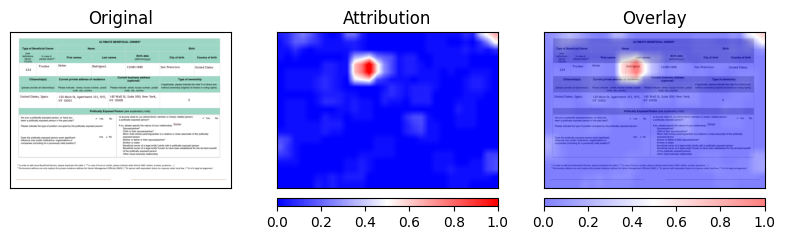

In [28]:
json_key = "Last names"
average = True # Average maps from all the tokens

plot_heatmap(json_key,
             res,
             average=average,
             idx=0)